In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [5]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "twitter_training.csv"
VALIDATION_PATH = PROJECT_ROOT / "data" / "twitter_validation.csv"

print("Training path:", TRAIN_PATH)
print("Validation path:", VALIDATION_PATH)
print("Training file exists:", TRAIN_PATH.exists())
print("Validation file exists:", VALIDATION_PATH.exists())

Training path: /home/jadkandah/progressSoft_internship/phase-1-machine-learning-nlp/assignment/data/twitter_training.csv
Validation path: /home/jadkandah/progressSoft_internship/phase-1-machine-learning-nlp/assignment/data/twitter_validation.csv
Training file exists: True
Validation file exists: True


In [6]:
COLUMN_NAMES = ["tweet_id", "entity", "sentiment", "text"]

train_df = pd.read_csv(
    TRAIN_PATH,
    header=None,
    names=COLUMN_NAMES
)

validation_df = pd.read_csv(
    VALIDATION_PATH,
    header=None,
    names=COLUMN_NAMES
)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

Training shape: (74682, 4)
Validation shape: (1000, 4)


In [7]:
display(train_df.head())
display(validation_df.head())

,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


,tweet_id,entity,sentiment,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [8]:
summary = pd.DataFrame({
    "training": [
        train_df.shape[0],
        train_df.shape[1],
        train_df.isna().sum().sum(),
        train_df.duplicated().sum()
    ],
    "validation": [
        validation_df.shape[0],
        validation_df.shape[1],
        validation_df.isna().sum().sum(),
        validation_df.duplicated().sum()
    ]
}, index=[
    "rows",
    "columns",
    "missing_values",
    "exact_duplicate_rows"
])

summary

,training,validation
rows,74682,1000
columns,4,4
missing_values,686,0
exact_duplicate_rows,2700,0


In [9]:
train_df["sentiment"].value_counts()

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [10]:
(
    train_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment
Negative      30.18
Positive      27.89
Neutral       24.53
Irrelevant    17.39
Name: proportion, dtype: float64

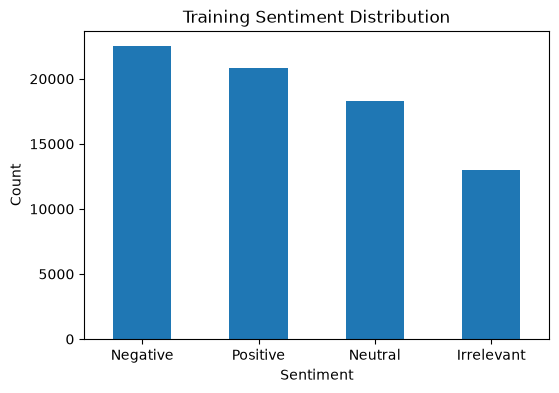

In [11]:
train_df["sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6, 4),
    title="Training Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [12]:
print("Unique entities:", train_df["entity"].nunique())

Unique entities: 32


In [13]:
for sentiment in train_df["sentiment"].unique():
    print(f"Sentiment: {sentiment}")

    print(
        train_df.loc[
            train_df["sentiment"] == sentiment,
            ["text"]
        ].head(1)
    )

Sentiment: Positive
                                                text
0  im getting on borderlands and i will murder yo...
Sentiment: Neutral
                                                 text
12  Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM...
Sentiment: Negative
                                                 text
24  the biggest dissappoinment in my life came out...
Sentiment: Irrelevant
                                                  text
102  Appreciate the (sonic) concepts / praxis Valen...


In [14]:
train_df.isna().sum()

tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64

In [15]:
train_df[train_df.isna().any(axis=1)].head(10)

,tweet_id,entity,sentiment,text
61,2411,Borderlands,Neutral,NaN
553,2496,Borderlands,Neutral,NaN
589,2503,Borderlands,Neutral,NaN
745,2532,Borderlands,Positive,NaN
1105,2595,Borderlands,Positive,NaN
1106,2595,Borderlands,Positive,NaN
2295,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2296,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2297,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2359,1613,CallOfDutyBlackopsColdWar,Irrelevant,NaN


In [16]:
print("Exact duplicate rows:", train_df.duplicated().sum())

print("Duplicate tweet text:", train_df["text"].duplicated().sum())

Exact duplicate rows: 2700
Duplicate tweet text: 5190
